# Random Forest Temperature Prediction

This notebook develops a machine learning approach to predict effective temperatures for eclipsing binaries using Random Forest regression.

## Motivation
- Photometric color-temperature relations have ~5-10% scatter
- Many objects lack Gaia temperatures but have complete photometry
- Random Forest can learn complex, non-linear relationships from data
- Can handle multiple correlated features and non-uniform errors

## Approach
1. **Feature Engineering**: Test correlations and select optimal features
2. **Adaptive Binning**: Create temperature classes with sufficient statistics
3. **Model Training**: Train Random Forest on objects with Gaia temperatures
4. **Validation**: Cross-validation and comparison with polynomial relations
5. **Prediction**: Apply to objects without Gaia temperatures

## Features to Consider
- **Colors**: g-r, r-i, i-z, B-V, V-K
- **Magnitudes**: g, r, i, z (apparent brightness)
- **Uncertainties**: Photometric errors (data quality indicator)
- **Astrometry**: Proper motion (distance/kinematics proxy)


In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Import utilities and config
from src.notebook_utils import load_ml_data, load_eb_catalog, load_panstarrs_data, RANDOM_STATE, TEST_SIZE
from src.config import get_config

# Get config
config = get_config()

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load data
print("Loading Pan-STARRS photometry with temperatures...")
panstarrs_data = load_panstarrs_data()
print(f"Loaded {len(panstarrs_data):,} objects")

print("\nLoading Gaia catalog with proper motion...")
gaia_data = load_eb_catalog()
print(f"Loaded {len(gaia_data):,} Gaia objects")

# Merge to get Gaia temperatures and astrometry
print("\nMerging datasets...")
data = panstarrs_data.merge(
    gaia_data[['original_ext_source_id', 'teff_gspphot', 'pmra', 'pmdec']], 
    on='original_ext_source_id', 
    how='inner'
)
print(f"Merged: {len(data):,} objects")

# Filter for objects with valid Gaia temperatures
valid_gaia_temp = (data['teff_gspphot'] > 0) & (data['teff_gspphot'] < 50000)
data_with_temp = data[valid_gaia_temp].copy()

print(f"\nObjects with valid Gaia T_eff: {len(data_with_temp):,}")
print(f"Temperature range: {data_with_temp['teff_gspphot'].min():.0f} - {data_with_temp['teff_gspphot'].max():.0f} K")
print(f"Median temperature: {data_with_temp['teff_gspphot'].median():.0f} K")

data_with_temp.head()

Objects with all features: 707,821


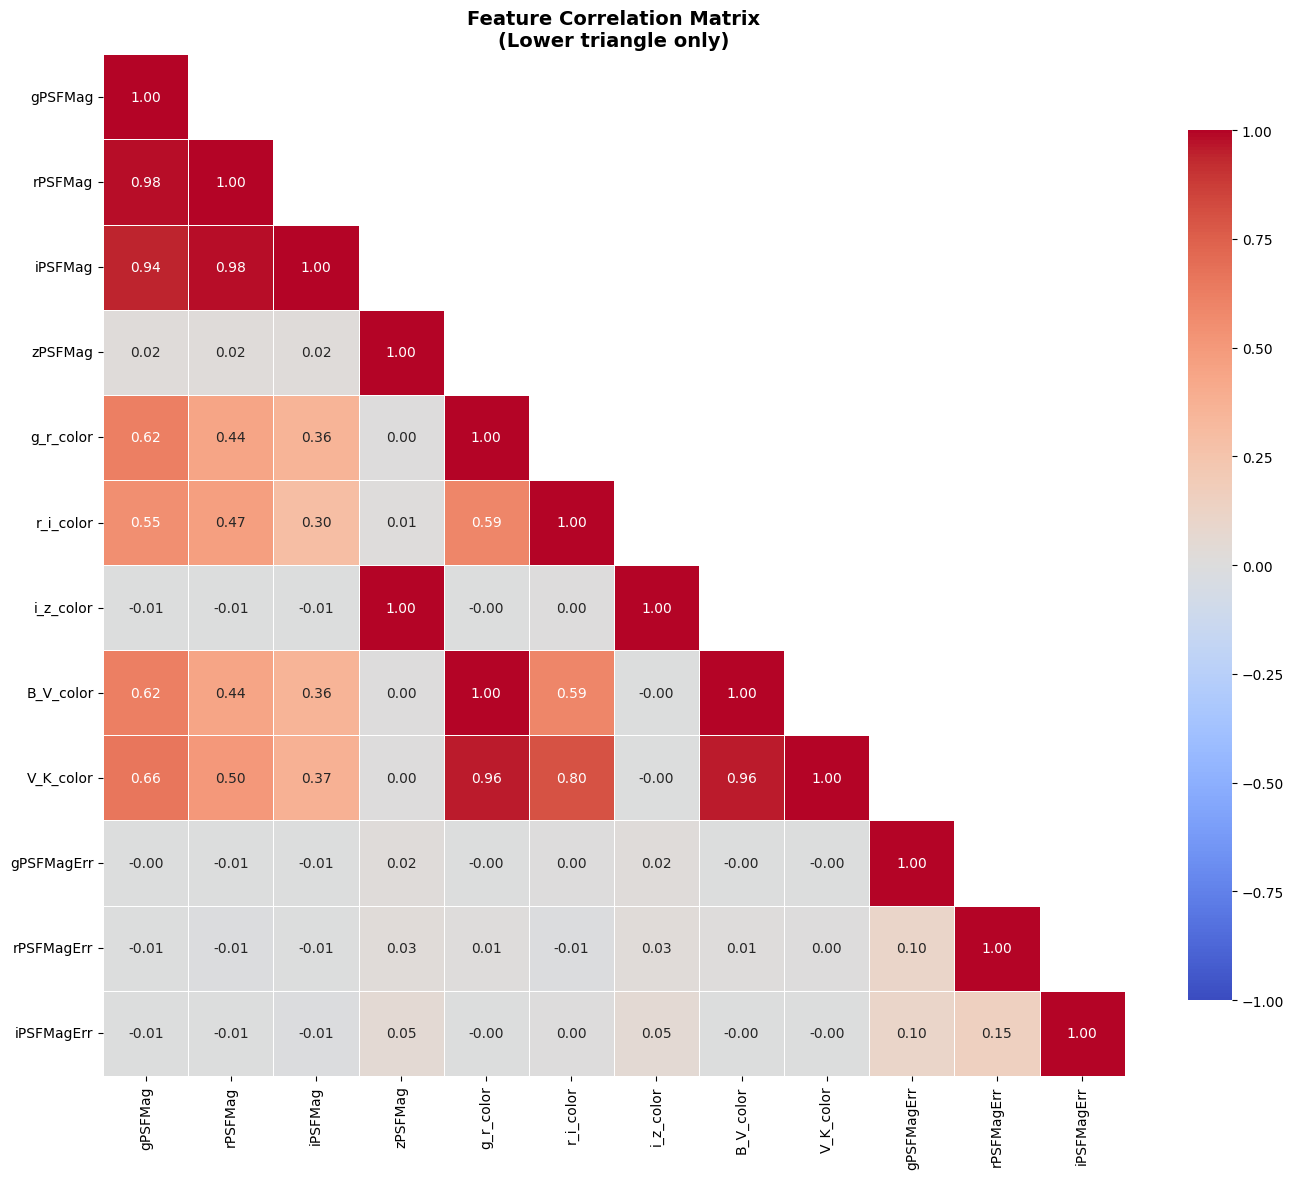


Highly correlated feature pairs (|r| > 0.7):
  gPSFMag         - rPSFMag        :  0.978
  gPSFMag         - iPSFMag        :  0.942
  rPSFMag         - iPSFMag        :  0.982
  zPSFMag         - i_z_color      :  1.000
  g_r_color       - B_V_color      :  1.000
  g_r_color       - V_K_color      :  0.955
  r_i_color       - V_K_color      :  0.802
  B_V_color       - V_K_color      :  0.955

Correlation with Gaia T_eff:
  i_z_color      :  0.005
  iPSFMagErr     :  0.004
  rPSFMagErr     :  0.003
  gPSFMagErr     :  0.003
  zPSFMag        : -0.008
  r_i_color      : -0.366
  g_r_color      : -0.445
  B_V_color      : -0.445
  V_K_color      : -0.463
  iPSFMag        : -0.563
  rPSFMag        : -0.593
  gPSFMag        : -0.622


In [6]:
# Feature Correlation Analysis
# Identify which features are redundant and which provide unique information

# Define candidate features (only photometric properties - intrinsic to the star)
candidate_features = [
    'gPSFMag', 'rPSFMag', 'iPSFMag', 'zPSFMag',  # Magnitudes
    'g_r_color', 'r_i_color', 'i_z_color',        # Pan-STARRS colors
    'B_V_color', 'V_K_color',                     # Synthetic colors
    'gPSFMagErr', 'rPSFMagErr', 'iPSFMagErr'      # Uncertainties (data quality)
]

# Note: We exclude proper motion (pmra, pmdec) because:
# 1. Not available for all objects
# 2. Kinematic properties shouldn't predict intrinsic physical properties

# Filter data for complete cases
feature_data = data_with_temp[candidate_features + ['teff_gspphot']].dropna()
print(f"Objects with all features: {len(feature_data):,}")

# Calculate correlation matrix
corr_matrix = feature_data[candidate_features].corr()

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Mask upper triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

ax.set_title('Feature Correlation Matrix\n(Lower triangle only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
print("\nHighly correlated feature pairs (|r| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"  {corr_matrix.columns[i]:15s} - {corr_matrix.columns[j]:15s}: {corr_val:6.3f}")

# Correlation with target (temperature)
temp_corr = feature_data[candidate_features].corrwith(feature_data['teff_gspphot']).sort_values(ascending=False)
print("\nCorrelation with Gaia T_eff:")
for feat, corr_val in temp_corr.items():
    print(f"  {feat:15s}: {corr_val:6.3f}")


In [11]:
# Select optimal features based on correlation analysis
# Remove highly correlated features to avoid redundancy

# Based on correlation analysis, select features that:
# 1. Have good correlation with temperature
# 2. Are not highly correlated with each other (< 0.9)
# 3. Provide complementary information

# Start with colors (primary temperature indicators)
selected_features = [
    'g_r_color',      # Primary color
    'r_i_color',      # Secondary color  
    'i_z_color',      # Tertiary color
    'B_V_color',      # Classical color (if not too correlated with g-r)
    # 'V_K_color',    # Often highly correlated with B-V, may skip
]

# Add representative magnitudes (brightness information)
# Note: Individual magnitudes are highly correlated, so pick one or use only colors
selected_features.extend([
    'gPSFMag',        # Reference magnitude
])

# Note: We skip magnitude errors (gPSFMagErr, etc.) because:
# 1. They also contain -999.0 missing values
# 2. Not very predictive for temperature
# 3. Would eliminate many otherwise good objects

print("Selected features for Random Forest:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# Prepare FULL dataset (complete cases only - no missing values)
# This is NOT training data yet - we'll split it in the next cell
print(f"\nFiltering for complete cases...")
print(f"  Starting with: {len(feature_data):,} objects (no NaN values)")

# Remove rows where any feature is -999.0 (missing data indicator)
complete_data = feature_data[selected_features + ['teff_gspphot']].copy()
for feat in selected_features:
    if feat in ['g_r_color', 'r_i_color', 'i_z_color']:  # Colors that use -999.0
        n_before = len(complete_data)
        complete_data = complete_data[complete_data[feat] != -999.0]
        n_removed = n_before - len(complete_data)
        if n_removed > 0:
            print(f"  Removed {n_removed:,} objects with {feat} = -999.0")

print(f"  After filtering: {len(complete_data):,} objects with complete photometry")

# Separate features and target for the FULL dataset
X_full = complete_data[selected_features].values
y_full = complete_data['teff_gspphot'].values

print(f"\nFull dataset (before train/test split):")
print(f"  Feature matrix X: {X_full.shape}")
print(f"  Target vector y: {y_full.shape}")
print(f"  Features: {len(selected_features)}")

# Display feature statistics
print(f"\nFeature ranges:")
for feat in selected_features:
    vals = complete_data[feat]
    print(f"  {feat:15s}: [{vals.min():8.3f}, {vals.max():8.3f}], median={vals.median():8.3f}")

print(f"\nTarget (T_eff) range: [{y_full.min():.0f}, {y_full.max():.0f}] K")


Selected features for Random Forest:
  1. g_r_color
  2. r_i_color
  3. i_z_color
  4. B_V_color
  5. gPSFMag

Filtering for complete cases...
  Starting with: 707,821 objects (no NaN values)
  Removed 1,823 objects with i_z_color = -999.0
  After filtering: 705,998 objects with complete photometry

Full dataset (before train/test split):
  Feature matrix X: (705998, 5)
  Target vector y: (705998,)
  Features: 5

Feature ranges:
  g_r_color      : [ -13.554,   16.295], median=   0.723
  r_i_color      : [ -15.419,   13.618], median=   0.353
  i_z_color      : [ -13.228,   10.599], median=   0.198
  B_V_color      : [ -11.851,   14.756], median=   0.876
  gPSFMag        : [   0.001,   28.385], median=  18.315

Target (T_eff) range: [2737, 31144] K


In [ ]:
# Save the cleaned dataset for ML training
# This dataset has complete photometry (no missing values) and valid Gaia temperatures

# Get processed data directory from config
processed_dir = config.get_path('data', 'processed', ensure_exists=True)
output_file = processed_dir / 'ml_training_data_clean.parquet'

print(f"Saving cleaned dataset for ML training...")
print(f"  Output: {output_file}")
print(f"  Objects: {len(complete_data):,}")
print(f"  Features: {selected_features}")
print(f"  Target: teff_gspphot")

# Get the IDs for the complete_data objects
# We need to match back to the original data_with_temp to get the IDs
complete_indices = complete_data.index
save_data = data_with_temp.loc[complete_indices].copy()

# Keep only the columns we need
save_columns = ['original_ext_source_id'] + selected_features + ['teff_gspphot']
save_data[save_columns].to_parquet(output_file, index=False)

print(f"✓ Saved successfully!")

# Verify the saved file
print(f"\nVerifying saved file...")
test_load = pd.read_parquet(output_file)
print(f"  Loaded: {len(test_load):,} objects, {len(test_load.columns)} columns")
print(f"  Columns: {list(test_load.columns)}")
print(f"  File size: {output_file.stat().st_size / 1024 / 1024:.1f} MB")

# Quick statistics
print(f"\nDataset statistics:")
print(f"  Temperature range: {test_load['teff_gspphot'].min():.0f} - {test_load['teff_gspphot'].max():.0f} K")
print(f"  Median temperature: {test_load['teff_gspphot'].median():.0f} K")
print(f"  No missing values: {test_load.isna().sum().sum() == 0}")
print(f"  No -999.0 values in colors: {(test_load[['g_r_color', 'r_i_color', 'i_z_color']] != -999.0).all().all()}")